In [6]:
import jax.numpy as jnp
import jax
from jax import jit,jacrev
import numpy as np
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices()[0])
from diffrax import diffeqsolve, Dopri5, ODETerm, SaveAt, PIDController
import equinox as eqx
jax.config.update('jax_enable_x64',True)
from evaluation_metrics import get_nrmse

from tqdm.auto import tqdm

from KernelTools import *

from Kernels import get_gaussianRBF, get_rq_kernel,get_centered_scaled_poly_kernel

from EquationModel import CholInducedRKHS, OperatorPDEModel,InducedOperatorModel

from Optimizers import CholeskyLM, LMParams

import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [7]:
def true_u(x):
    numerator = 18*(18*jnp.exp(3*x+1) + 4*jnp.exp(4*x+2) + jnp.exp(5*x+1) + 9*jnp.exp(x+1) + 36*jnp.exp(2*x))
    denom = 9+9*jnp.exp(x+1) + 9*jnp.exp(2*x) + jnp.exp(3*x+1)
    denom = denom**2
    return numerator/denom

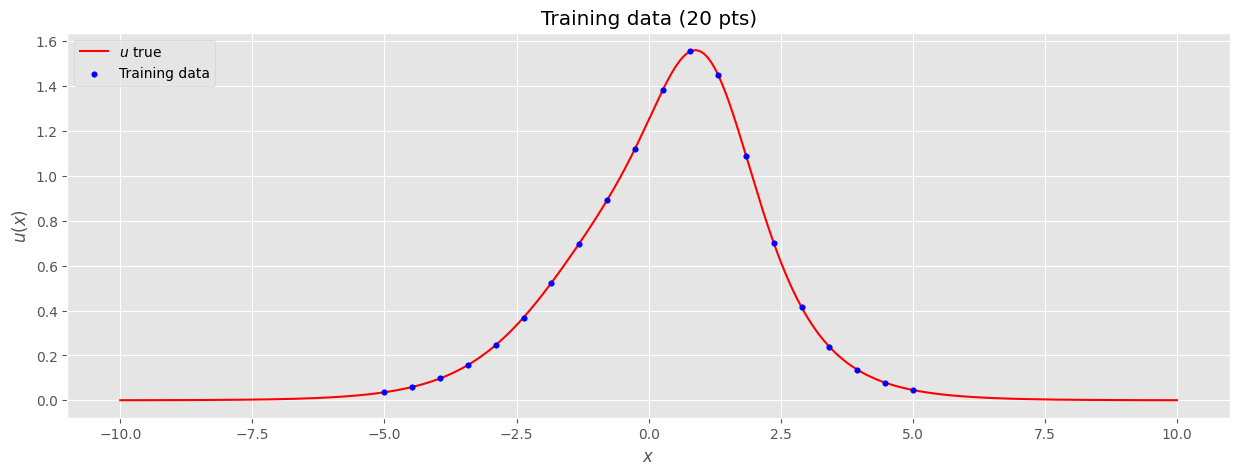

In [8]:
plt.figure(figsize=(15,5))
x0 = -10
x1 = 10
# Fine grid
xvals = jnp.linspace(x0,x1,5000)
# u(Fine grid)
u_full = jax.vmap(true_u)(xvals)
plt.plot(xvals,u_full, c = 'red', label = '$u$ true')

num_obs = 20

x0_obs = -5
x1_obs = 5
x_obs = jnp.linspace(x0_obs,x1_obs,num_obs)
u_obs = jax.vmap(true_u)(x_obs)
plt.scatter(x_obs,u_obs, s=15,c= 'blue',zorder = 100, label = 'Training data')
plt.title(f'Training data ({num_obs} pts)')
plt.ylabel('$u(x)$')
plt.xlabel('$x$')
plt.legend(loc = 'upper left')
plt.show()

In [ ]:
def get_nth_derivative_k(n):
    def op(k,index=0):
        result = k
        for i in range(n):
            result = dt_k(k,index)
        return result
    return op
ddx = get_nth_derivative_k(1)
d2dx2 = get_nth_derivative_k(2)
d3dx3 = get_nth_derivative_k(3)

u_operators = (eval_k,ddx,d2dx2,d3dx3)

feature_operators = (eval_k,)

k_u = get_gaussianRBF(1.)
num_colloc = 1000
x_grid = jnp.linspace(x0,x1,num_colloc).reshape(-1,1)

u_model = CholInducedRKHS(
    x_grid,
    u_operators,
    k_u,
    nugget_size = 1e-8
    )

u_params_init = u_model.get_fitted_params(x_obs,u_obs)

grid_features_init = (
    (u_model.evaluate_operators(feature_operators,x_grid,u_params_init))
    .reshape(
            len(x_grid),
            len(feature_operators),
            order = 'F'
        )
)
grid_features_init = jnp.hstack([x_grid,grid_features_init])
num_P_inducing = 100
P_inducing_points = jax.random.choice(jax.random.PRNGKey(13),grid_features_init,(num_P_inducing,))

k_P_u_part = get_centered_scaled_poly_kernel(1,grid_features_init[:,1:])
def k_P(x,y):
    return k_P_u_part(x[1:],y[1:])
P_model = InducedOperatorModel(P_inducing_points,k_P)

ValueError: diag input must be 1d or 2d

: 

In [ ]:
EqnModel = OperatorPDEModel(
    P_model,
    (u_model,),
    (x_obs,),
    (u_obs,),
    (x_grid,),
    feature_operators,
    rhs_operator=d3dx3,
    datafit_weight = 1,
    rhs_forcing_values = None,
    num_P_operator_params = num_P_inducing
)

utt_init = EqnModel.apply_rhs_op_single(u_model,u_params_init,EqnModel.collocation_points[0])
P_params_init = P_model.get_fitted_params(grid_features_init,utt_init,lam = 1e-3)
params_init = jnp.hstack([u_params_init,P_params_init])

In [ ]:
optParams = LMParams(max_iter = 1001,
                     min_alpha = 1e-9,
                     tol = 1e-15
                     )
sol, convergence_data = CholeskyLM(params_init,EqnModel,beta = 1e-16,optParams = optParams) 

In [ ]:
u_params = EqnModel.get_u_params(sol)[0]
P_params = EqnModel.get_P_params(sol)

In [ ]:
u_pred = u_model.point_evaluate(xvals,u_params)
u_pred_init = u_model.point_evaluate(xvals,u_params_init)
plt.figure(figsize=(12,5))
plt.plot(xvals,u_pred,label = "KEQL Result")
plt.plot(xvals,u_pred_init,label = 'Kernel Regression')
plt.scatter(x_obs,u_obs)
plt.plot(xvals,u_full,label = "True Solution")
plt.legend()
plt.yscale('log')

In [ ]:
u_pred = u_model.point_evaluate(xvals,u_params)
u_pred_init = u_model.point_evaluate(xvals,u_params_init)
plt.figure(figsize=(12,5))
plt.plot(xvals,u_pred-u_full,label = "KEQL error")
plt.plot(xvals,u_pred_init - u_full,label = 'Kernel Regression error')
plt.legend()


In [ ]:
EqnModel.stacked_equation_residual((u_params,),P_params)